# Tutorial Notebook

This notebook is a practical walk-through for the [amortized Bayesian workflow](https://openreview.net/forum?id=osV7adJlKD). The core idea of the workflow is: train one amortized posterior estimator/surrogate once, then reuse it across many datasets and escalate to more expensive but accurate methods (Pareto-smoothed importance sampling, MCMC sampling) when diagnostics require it. With this approach we can achieve efficiency gains while maintaining high posterior quality.

In brief, the main steps are:

- Training phase: train an amortized estimator and validate it with simulated datasets.
- Inference phase (Step 1): fast amortized draws for real datasets + out-of-distribution (OOD) diagnostic for flagging datasets where the amortized draws may be unreliable
- Inference phase (Step 2): Pareto-smoothing importance sampling correction + Pareto-$\hat{k}$ diagnostic
- Inference phase (Step 3): MCMC sampling with amortized initializations + R-hat convergence diagnostic

This notebook goes through each step from training to inference and allows you to inspect intermediate outputs and reuse the same pattern for your own tasks.


We first install the required dependencies. If you are running this notebook in Google Colab, the installation will be done for you and the runtime will be automatically restarted after installation. If you are running this notebook in your local environment, please make sure you have installed the package in your Python environment (see [README](https://github.com/pipme/amortized-Bayesian-workflow/?tab=readme-ov-file#install) for details).


In [1]:
import importlib.util
import subprocess
import sys

COLAB = "google.colab" in sys.modules
USE_GPU_IN_COLAB = False  # True for GPU runtime
AUTO_RESTART_AFTER_INSTALL = True


def _has_module(name: str) -> bool:
    return importlib.util.find_spec(name) is not None


if COLAB and not _has_module("amortized_bayesian_workflow"):

    def _pip_install(*args: str) -> None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *args])

    _pip_install(
        "--upgrade", "--no-cache-dir", "--force-reinstall", "numpy>=2.2.6"
    )

    extras = "[all,gpu]" if USE_GPU_IN_COLAB else "[all]"
    _pip_install(
        "--upgrade",
        "--no-cache-dir",
        f"git+https://github.com/pipme/amortized-Bayesian-workflow.git#egg=amortized-bayesian-workflow{extras}",
    )

    print("Dependencies installed.")
    if AUTO_RESTART_AFTER_INSTALL:
        print("Restarting runtime now...")
        exit()
elif COLAB:
    print("Dependencies already installed. Continue to next cell.")

# Local clone alternatives:
#   CPU/default: pip install -e '.[all]'
#   CUDA GPU: pip install -e '.[all,gpu]'

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"
import jax
import numpy as np
import bayesflow as bf
import matplotlib.pyplot as plt

from amortized_bayesian_workflow import (
    ArtifactLayout,
    InferenceConfig,
    InferenceRunner,
)
from amortized_bayesian_workflow.approximators import (
    BayesFlowAmortizedPosterior,
)
from amortized_bayesian_workflow.backends import run_mcmc
from amortized_bayesian_workflow.psis import (
    compute_psis,
    resample_with_weights,
)
from amortized_bayesian_workflow import configure_logging

configure_logging(
    "WARNING",
    external_loggers=["pymc.sampling.forward"],
)
print(f"BayesFlow version: {bf.__version__}")
print(f"JAX devices available: {jax.devices()}")

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/lichengk/.miniforge3/envs/python312test/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/lichengk/.miniforge3/envs/python312test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed


BayesFlow version: 2.0.10
JAX devices available: [CpuDevice(id=0)]


## Training phase: train an amortized estimator

An amortized posterior estimator takes in an observed data and outputs an approximation to the posterior distribution. It can be trained with simulated parameter and data pairs from the probabilistic model (prior predictive distribution), which is also known as **simulation-based inference (SBI)** in the literature. Here we use [BayesFlow](https://github.com/bayesflow-org/bayesflow) package for this purpose, which provide convenient APIs for building, training and validating amortized estimators.


Here we use the psychometric curve fitting example task from the paper. This task was implemented by wrapping a PyMC model into a format compatible with BayesFlow for amortized inference. Throughout the workflow, by default we operate in the unconstrained space of the model parameters so that there is no worry about parameter constraints (e.g., positive parameters). One can also define a task by providing a function for prior predictive simulation (`simulate_prior_predictive`) or follow `BayesFlow`'s documentation for various use cases.


In [3]:
from amortized_bayesian_workflow.tasks.examples import (
    PsychometricTask,
)
from pathlib import Path

task = PsychometricTask(overdispersion=True)
layout = ArtifactLayout(
    root=Path("./artifacts"),
    task_name=task.task_name,
)
layout.ensure()

ArtifactLayout(root=PosixPath('artifacts'), task_name='psychometric_curve_overdispersion', run_name='default')

In [4]:
from bayesflow.workflows import BasicWorkflow
from bayesflow.diagnostics import plots as bf_plots

import keras
from amortized_bayesian_workflow.utils import read_from_file

num_train_simulations = 10000
num_validation_simulations = 500
batch_size = 256
epochs = 100
seed = 2026
keras.utils.set_random_seed(seed)


train_sims = task.simulate_prior_predictive(num_train_simulations, seed=seed)
val_sims = task.simulate_prior_predictive(
    num_validation_simulations, seed=seed + 1
)
diagnostic_sims = task.simulate_prior_predictive(200, seed=seed + 2)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)
INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - loss: 7.0001 - val_loss: 6.4448
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 6.6301 - val_loss: 6.2834
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 6.5312 - val_loss: 6.2391
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 6.4539 - val_loss: 6.1500
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 6.3182 - val_loss: 5.9287
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 6.0486 - val_loss: 5.5078
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 5.8493 - val_loss: 5.2885
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 5.6773 - val_loss: 5.2540
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.5212 - val_loss: 5.1410
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 5.3485 - val_loss: 5.0375
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 5.1950 - val_loss: 4.7362
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/st

INFO:bayesflow:Training completed in 2.60 minutes.
INFO:bayesflow:Training is now finished.
            You can find the trained approximator at 'artifacts/psychometric_curve_overdispersion/default/models/best_model.best_model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


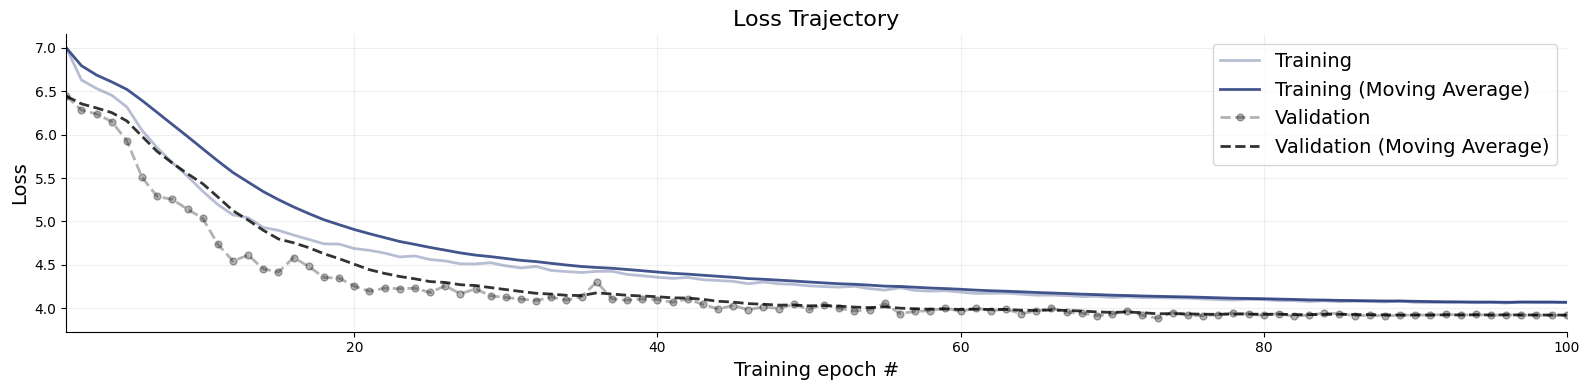

In [5]:
adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")
    .rename("parameters", "inference_variables")
    .rename("observables", "summary_variables")
)
inference_network = bf.networks.CouplingFlow()
summary_network = bf.networks.DeepSet()

basic_amortized_workflow = BasicWorkflow(
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    checkpoint_filepath=layout.models_dir,
    checkpoint_name="best_model",
    save_best_only=True,
)


history = basic_amortized_workflow.fit_offline(
    data=train_sims,
    validation_data=val_sims,
    epochs=epochs,
    batch_size=batch_size,
)
_ = bf_plots.loss(history)

# Load the best model for inference and diagnostics
basic_amortized_workflow.approximator = keras.saving.load_model(
    layout.models_dir / "best_model.keras"
)

After training, we can validate the amortized estimator with simulated data. This validation step is important for checking the quality of the amortized estimator before applying it to real data. We recommend simulation-based calibration (SBC) and parameter recovery checking in particular. `BayesFlow` also provides other diagnostic plots such as coverage plots and posterior variance contraction plots, which can be useful as well.

From SBC and parameter recovery plots (the first and second figures in the next cell's output), we can see that the trained amortized estimator is well-calibrated but some parameters are hard to recover. Simulation-based calibration is required for a correct posterior while parameter recovery is not always expected (e.g., due to weak identifiability of model parameters given limited observations). Since SBC is passed and from the plots the amortized estimator is effectively learning the posterior, we can decide to proceed to the inference phase and use the amortized estimator for inference on real data, proposals for importance sampling correction and initializations for MCMC sampling. It is also possible to go back and further improve the amortized estimator (e.g., by training with more data, tuning the architecture, etc.). See Section 2.1 and Appendix B of the paper for more discussions.


Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.20s/batch]


Diagnostic plots for the amortized estimator:


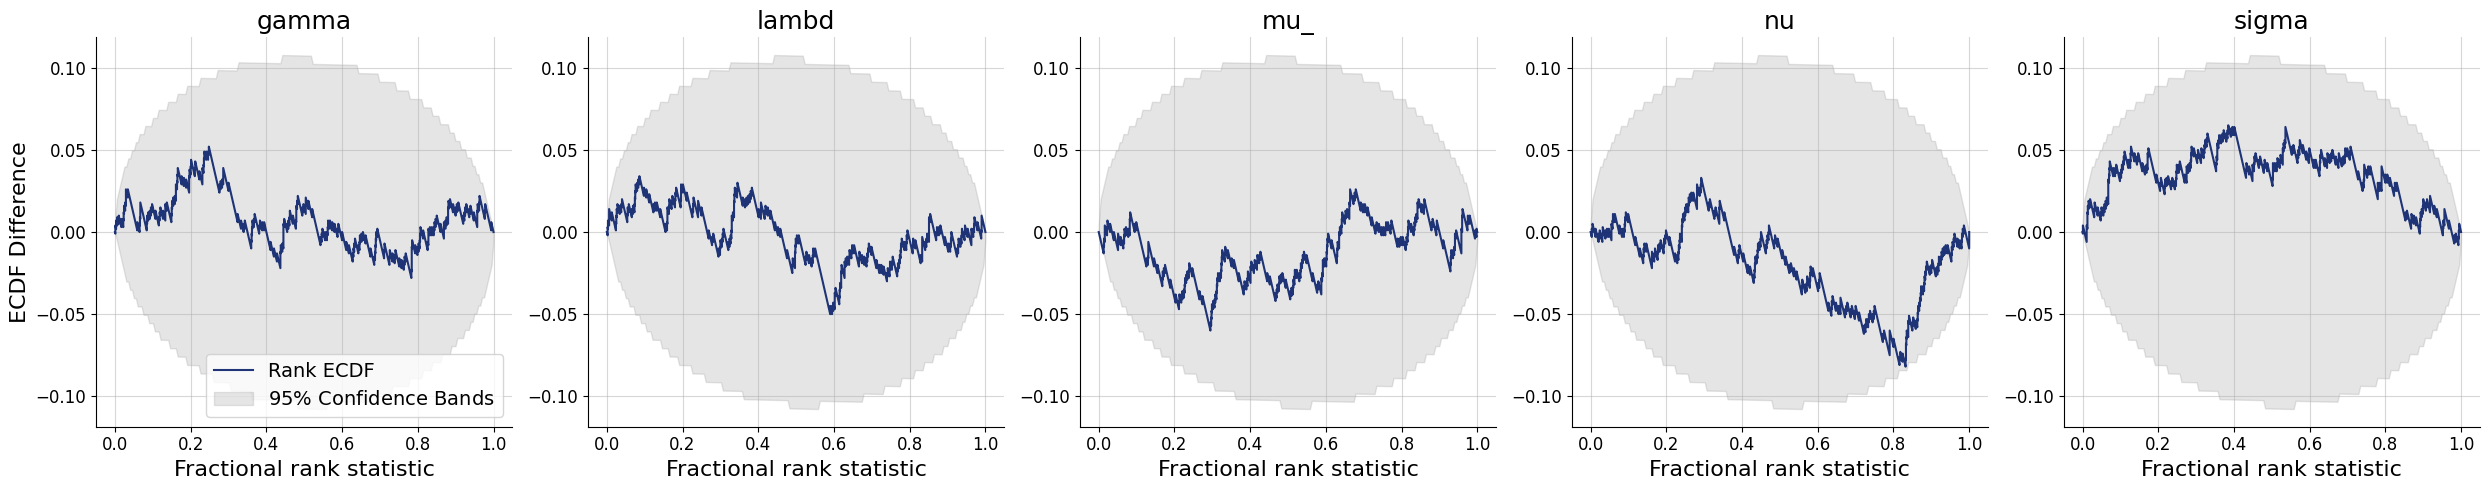

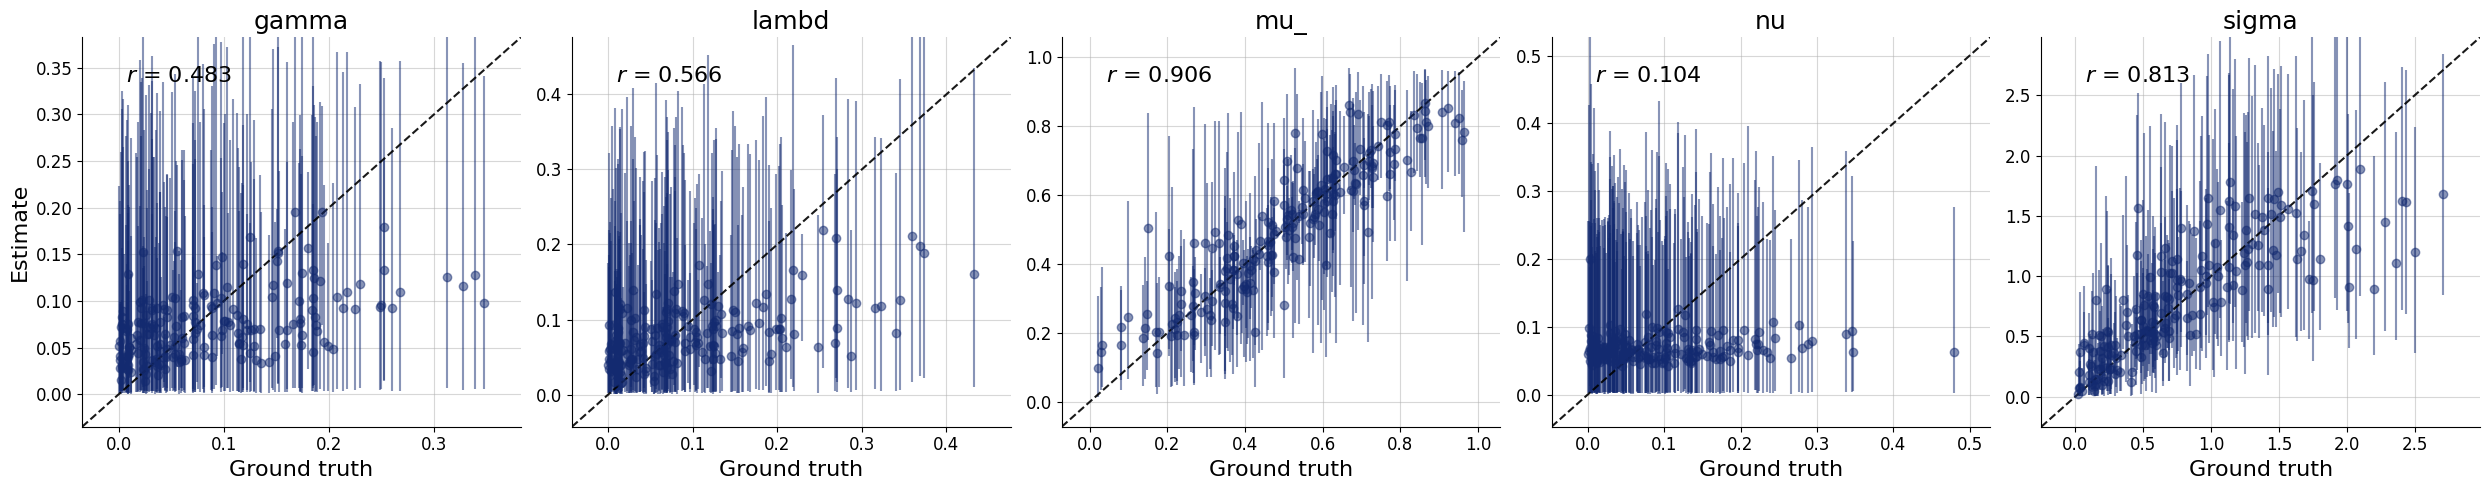

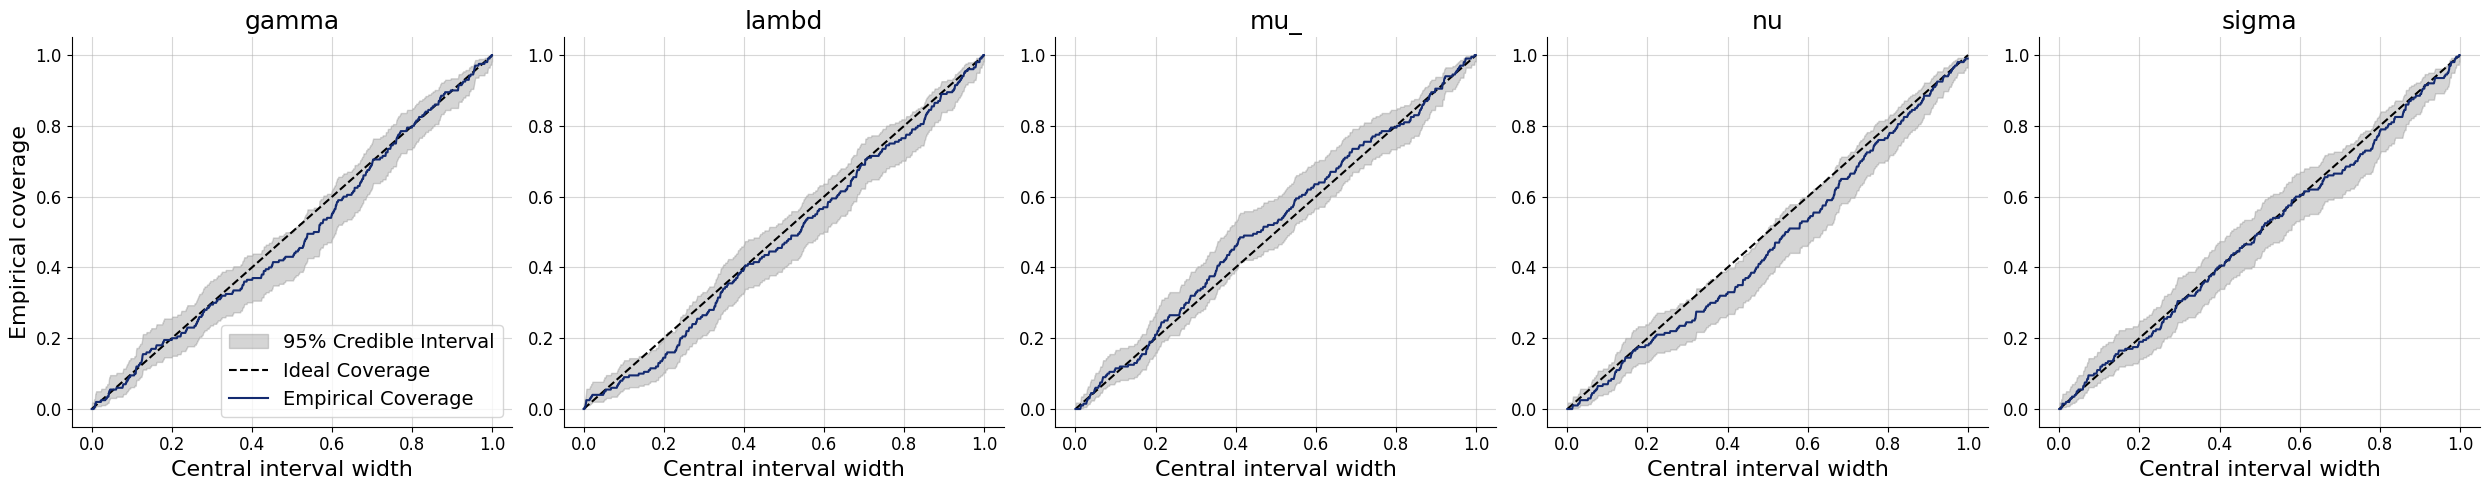

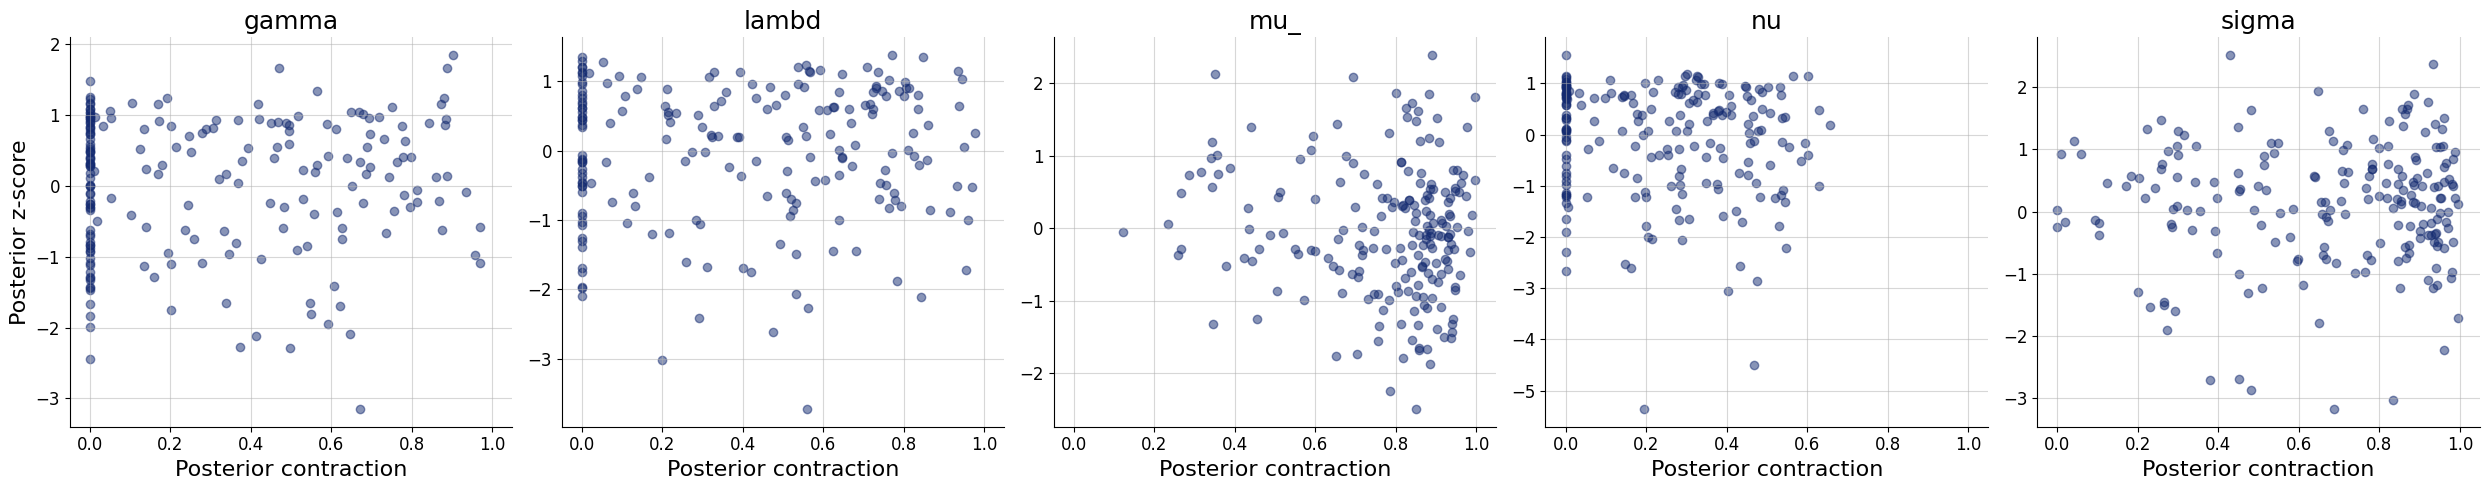

In [6]:
plot_fns = {
    "calibration_ecdf": bf_plots.calibration_ecdf,
    "recovery": bf_plots.recovery,  # By default it shows the median and 95% credible interval of the posterior estimates for each parameter
    "coverage": bf_plots.coverage,
    "z_score_contraction": bf_plots.z_score_contraction,
}

post_draws = basic_amortized_workflow.approximator.sample(
    conditions=diagnostic_sims, num_samples=1000
)
# We transform to the original parameter space for better interpretability of the diagnostic plots, but this is optional.
estimates = task.transform_to_constrained_space(
    post_draws["parameters"].reshape(-1, post_draws["parameters"].shape[-1])
).reshape(post_draws["parameters"].shape)
targets = task.transform_to_constrained_space(diagnostic_sims["parameters"])

print("Diagnostic plots for the amortized estimator:")
for k, plot_fn in plot_fns.items():
    _ = plot_fn(
        estimates=estimates,
        targets=targets,
        variable_names=task.axis_names_for_corner_plot(value_var=False),
    )

In [7]:
# Wrap the trained approximator and cache summary statistics of training data for OOD detection later.
approximator = BayesFlowAmortizedPosterior(
    basic_amortized_workflow.approximator
)
approximator.store_training_summaries(train_sims["observables"])
print(f"Summary statistics shape: {approximator.training_summaries.shape}")

# We can save the approximator to disk and load it for reuse in future.
approximator.save(layout.models_dir)

Summary statistics shape: (10000, 16)


## Inference phase


Once we have a trained amortized estimator and validated it on simulated data, we can apply it to real data for inference.


In [ ]:
# Construct `InferenceRunner` with the trained amortized estimator.

config = InferenceConfig(seed=2026)
runner = InferenceRunner(task=task, approximator=approximator, config=config)

## Step 1: amortized posterior draws


In [9]:
from amortized_bayesian_workflow.utils import read_from_file

# We read 100 real datasets from disk for testing.
test_observations = read_from_file(task.task_info_dir / "test_datasets.pkl")[
    :100
]

In [10]:
amortized_batch = approximator.sample_and_log_prob_batch(
    test_observations, num_samples=config.num_amortized_draws, seed=config.seed
)
print(
    f"Amortized inference on {len(amortized_batch)} test datasets, each with {config.num_amortized_draws} posterior draws."
)


Sampling: 100%|██████████| 1/1 [00:00<00:00,  1.12batch/s]


Amortized inference on 100 test datasets, each with 2000 posterior draws.


## Step 1 diagnostic: OOD detection with Mahalanobis distance

The amortized estimator can provide fast posterior draws, but they may be unreliable if the real data is out-of-distribution (OOD) compared to the simulated data used for training. Therefore, we need diagnostics to flag such datasets and proceed them with PSIS corrections (Step 2) or MCMC sampling (Step 3).

We use Mahalanobis distance on summary statistics to flag out-of-distribution datasets. Datasets passing this diagnostic can accept amortized draws directly; rejected datasets proceed to Step 2. It is important to note that the OOD diagnostic is not perfect and may have false positives or false negatives. For some applications, it may be desirable to proceed all datasets to Step 2 regardless of the OOD diagnostic. See the paper for more discussion on this point.

We plot the OOD diagnostic results to inspect how many datasets are flagged as OOD and how they differ from Mahalanobis distances of the training data.


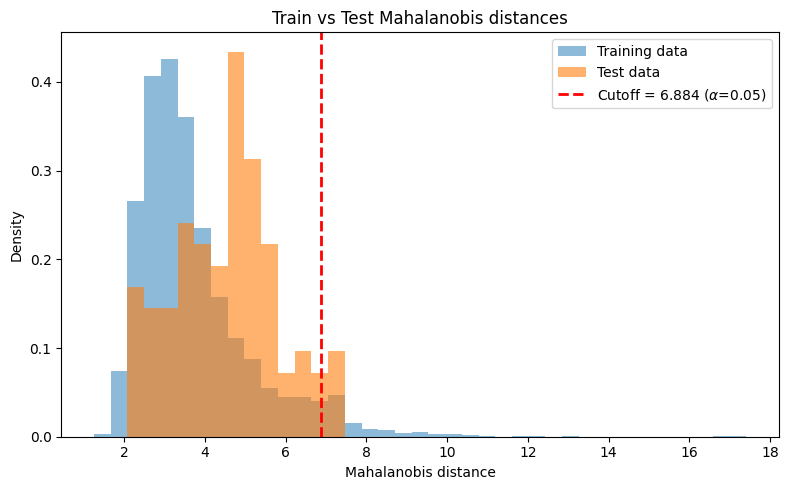

In [11]:
runner.compute_mahalanobis_reference()  # Use the summary statistics of the training datasets to define the Mahalanobis distance

train_stats = runner.mahalanobis_reference.train_statistics
all_summaries = runner.summary_statistics(test_observations)
ood_results = runner.mahalanobis_reference.evaluate_batch(
    all_summaries, alpha=runner.config.mahalanobis_alpha
)
test_stats = np.array([r.statistic for r in ood_results], dtype=float)
cutoff = runner.mahalanobis_reference.threshold(
    alpha=runner.config.mahalanobis_alpha
)

bins = np.linspace(
    min(train_stats.min(), test_stats.min()),
    max(train_stats.max(), test_stats.max()),
    40,
)

plt.figure(figsize=(8, 5))
plt.hist(
    train_stats, bins=bins, density=True, alpha=0.5, label="Training data"
)
plt.hist(test_stats, bins=bins, density=True, alpha=0.6, label="Test data")
plt.axvline(
    cutoff,
    color="red",
    linestyle="--",
    linewidth=2,
    label=rf"Cutoff = {cutoff:.3f} ($\alpha$={runner.config.mahalanobis_alpha})",
)
plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Train vs Test Mahalanobis distances")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# Get the dataset flagged as OOD and the one flagged as in-distribution
ood_indices = np.where(test_stats > cutoff)[0]
ind_indices = np.where(test_stats <= cutoff)[0]
print(
    f"Number of test datasets flagged as OOD: {len(ood_indices)} out of {len(test_stats)}"
)


i = ood_indices[0]  # We take the first OOD dataset for inspection.
# i = ind_indices[0]  # We can also inspect the in-distribution datasets.
observation = test_observations[i]
posterior_draws_amortized = amortized_batch[i].samples
log_q = amortized_batch[i].log_prob
posterior_draws_amortized.shape, log_q.shape

Number of test datasets flagged as OOD: 6 out of 100


((2000, 5), (2000,))

## Step 2: Pareto-smoothed importance sampling (PSIS)

PSIS reweights amortized draws by smoothing the importance ratios of the target posterior density and proposal density. The Pareto-$\hat{k}$ diagnostic tells whether corrected draws are reliable ($\hat{k}<0.7$) or should escalate to Step 3 ($\hat{k}>0.7$).


In [13]:
log_post_vec = task.vectorized_log_posterior_fn(observation)
log_target = log_post_vec(posterior_draws_amortized)
psis = compute_psis(log_target=log_target, log_proposal=log_q)

print(
    f"Dataset index: {i}, Pareto k estimates: {psis.pareto_k:<.3f}, Effective sample size: {psis.ess:.1f}"
)
if psis.is_reliable:
    print("PSIS correction is reliable for this dataset.")
else:
    print(
        "PSIS correction may not be reliable for this dataset, consider proceeding to MCMC sampling in Step 3."
    )

Dataset index: 4, Pareto k estimates: 0.518, Effective sample size: 697.4
PSIS correction is reliable for this dataset.


We can also visualize the resampled posterior draws after PSIS correction and the original amortized draws together to see how much correction is applied by PSIS. For datasets flagged as OOD in Step 1, we often see more significant corrections by PSIS compared to in-distribution datasets.


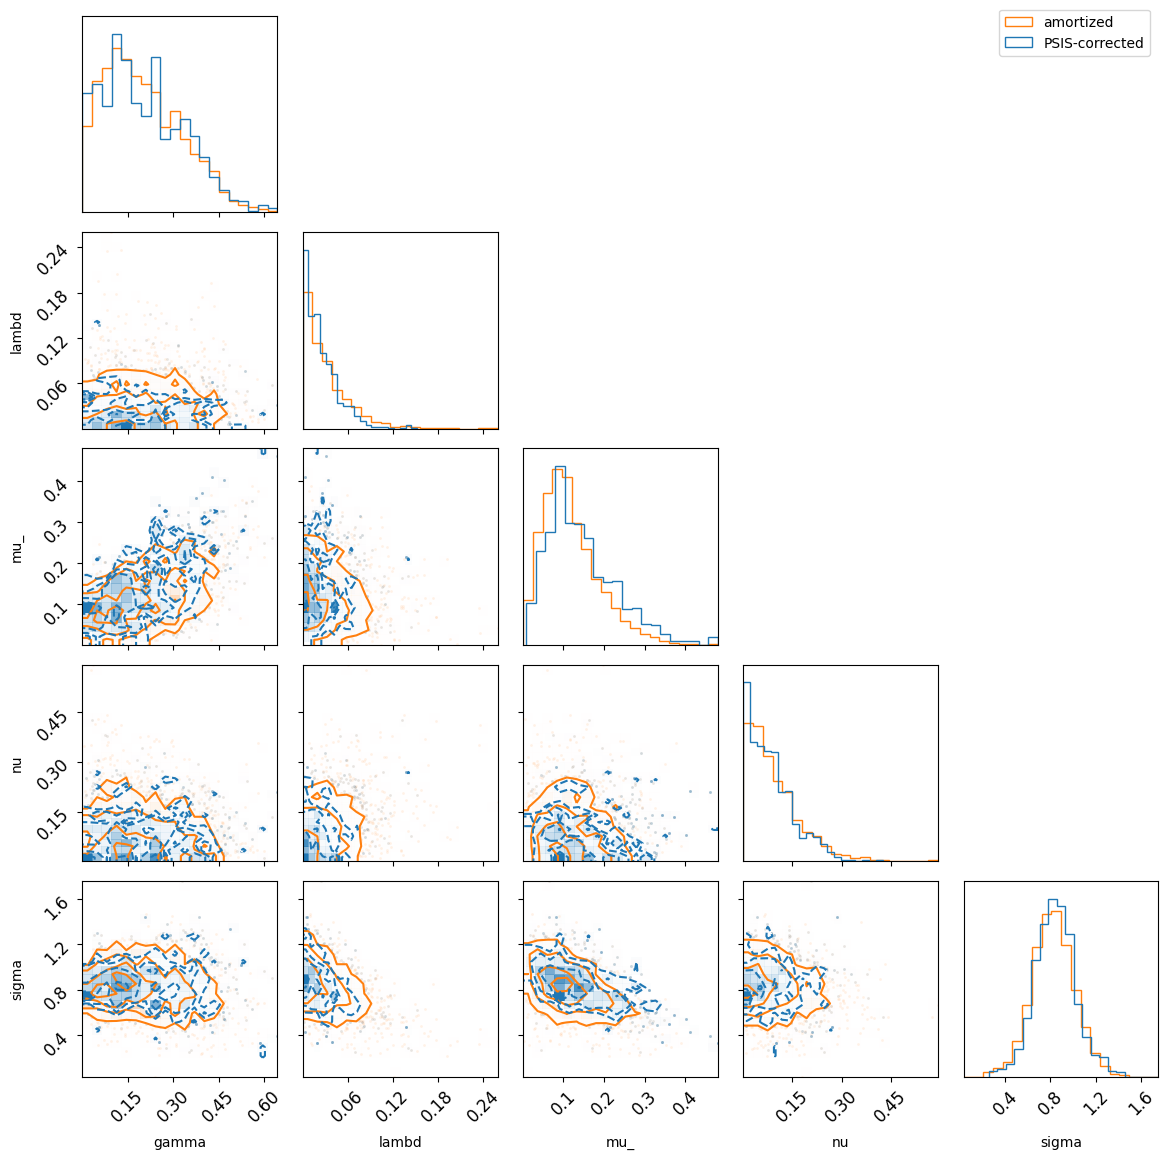

In [14]:
from amortized_bayesian_workflow.utils import corner_plot

posterior_draws_psis = resample_with_weights(
    samples=posterior_draws_amortized,
    weights=psis.smoothed_normalized_weights,
    num_draws=len(posterior_draws_amortized),
    replace=True,
)
_ = corner_plot(
    posterior_draws_amortized,
    posterior_draws_psis,
    labels=["amortized", "PSIS-corrected"],
    var_names=task.var_names,
    transform=task.transform_to_constrained_space,
)

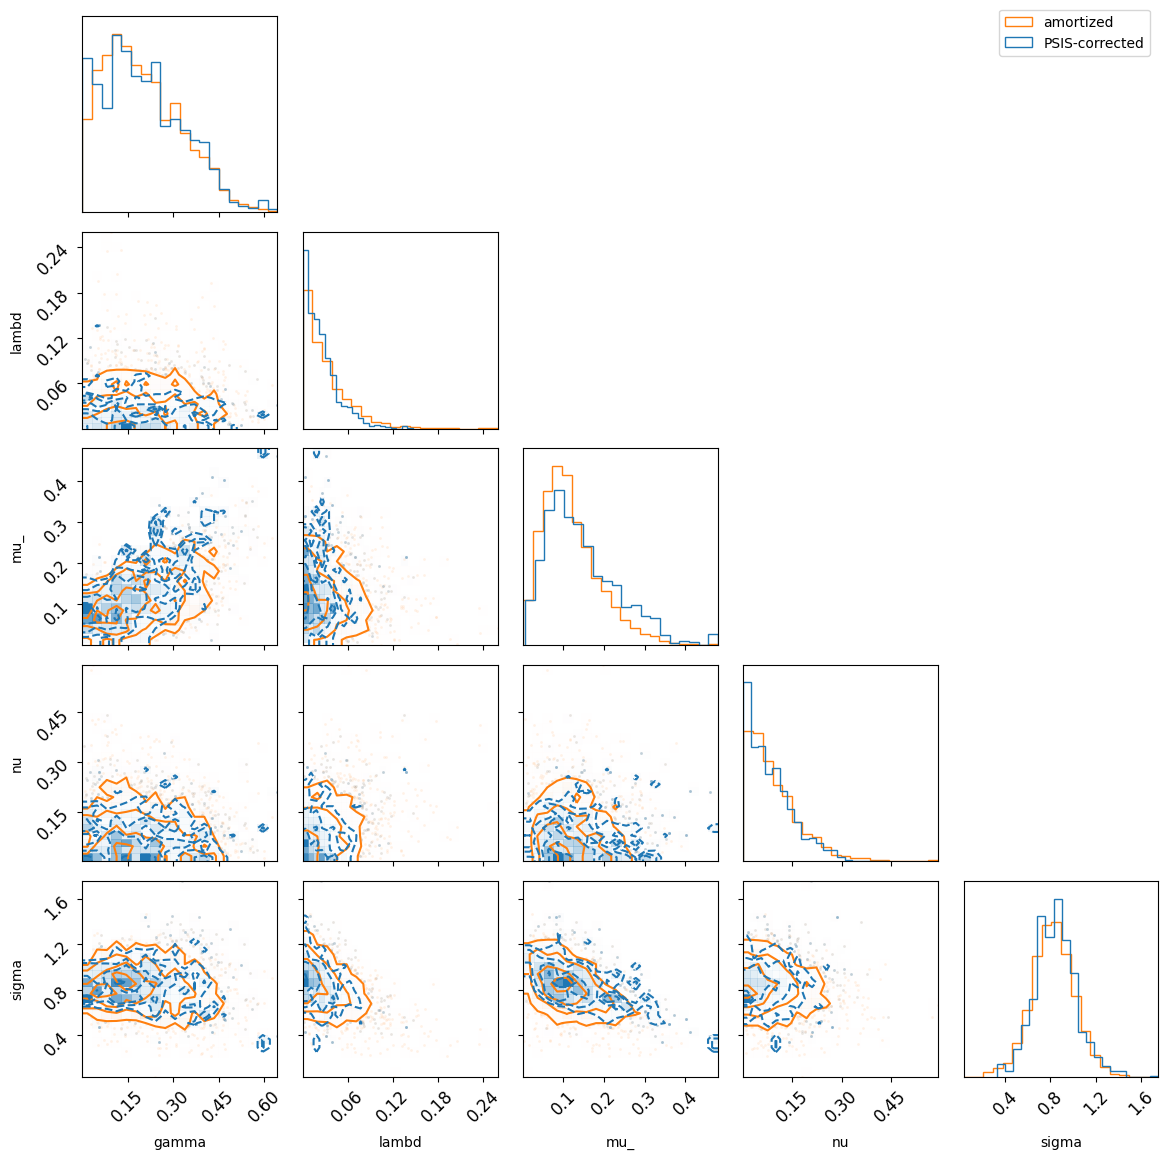

In [15]:
from amortized_bayesian_workflow.utils import corner_plot

posterior_draws_psis = resample_with_weights(
    samples=posterior_draws_amortized,
    weights=psis.smoothed_normalized_weights,
    num_draws=len(posterior_draws_amortized),
    replace=True,
)
_ = corner_plot(
    posterior_draws_amortized,
    posterior_draws_psis,
    labels=["amortized", "PSIS-corrected"],
    var_names=task.var_names,
    transform=task.transform_to_constrained_space,
)

## Step 3: MCMC sampling with amortized initializations

If PSIS is not reliable as indicated by the Pareto-$\hat{k}$ diagnostic, we run MCMC and initialize chains from amortized draws. This reuse strategy can reduce the warmup time and thus improve efficiency. Here we use the ChEES-HMC sampler as an example, which launches many short chains (e.g., 2048) in parallel and is designed to work with SIMD hardware like GPUs.


In [16]:
backend_name = "blackjax_chees_hmc"
# backend_name = "blackjax_nuts"
# backend_name = "tfp_chees_hmc"  # Requires TFP installation and version compatibility
iter_warmup = 200

if backend_name in ["blackjax_chees_hmc", "tfp_chees_hmc"]:
    options = {"num_superchains": 16, "subchains_per_superchain": 128}
    iter_sampling = 1
    initial_positions = posterior_draws_amortized[: options["num_superchains"]]
elif backend_name == "blackjax_nuts":
    options = {"num_chains": 4}
    iter_sampling = 500
    initial_positions = posterior_draws_amortized[: options["num_chains"]]
else:
    raise ValueError(f"Unsupported backend: {backend_name}")

log_post_single = task.single_log_posterior_fn(
    observation
)  # Use a non-vectorized log-prob function for MCMC sampling, since most MCMC backends expect that.
mcmc_result = run_mcmc(
    backend_name=backend_name,
    initial_positions=initial_positions,
    log_prob_fn=log_post_single,
    iter_warmup=iter_warmup,
    iter_sampling=iter_sampling,
    options=options,
    seed=seed,
)

print(
    f"""MCMC backend used: {mcmc_result.backend}
MCMC draws shape: {mcmc_result.draws.shape}
{mcmc_result.rhat_name}: {mcmc_result.diagnostics.get(mcmc_result.rhat_name)}
Convergence:{mcmc_result.is_converged(threshold=1.01)}"""
)

MCMC backend used: blackjax_chees_hmc
MCMC draws shape: (2048, 1, 5)
nested_rhat: [1.00315506 1.00282829 1.00324982 1.00464046 1.00479115]
Convergence:True


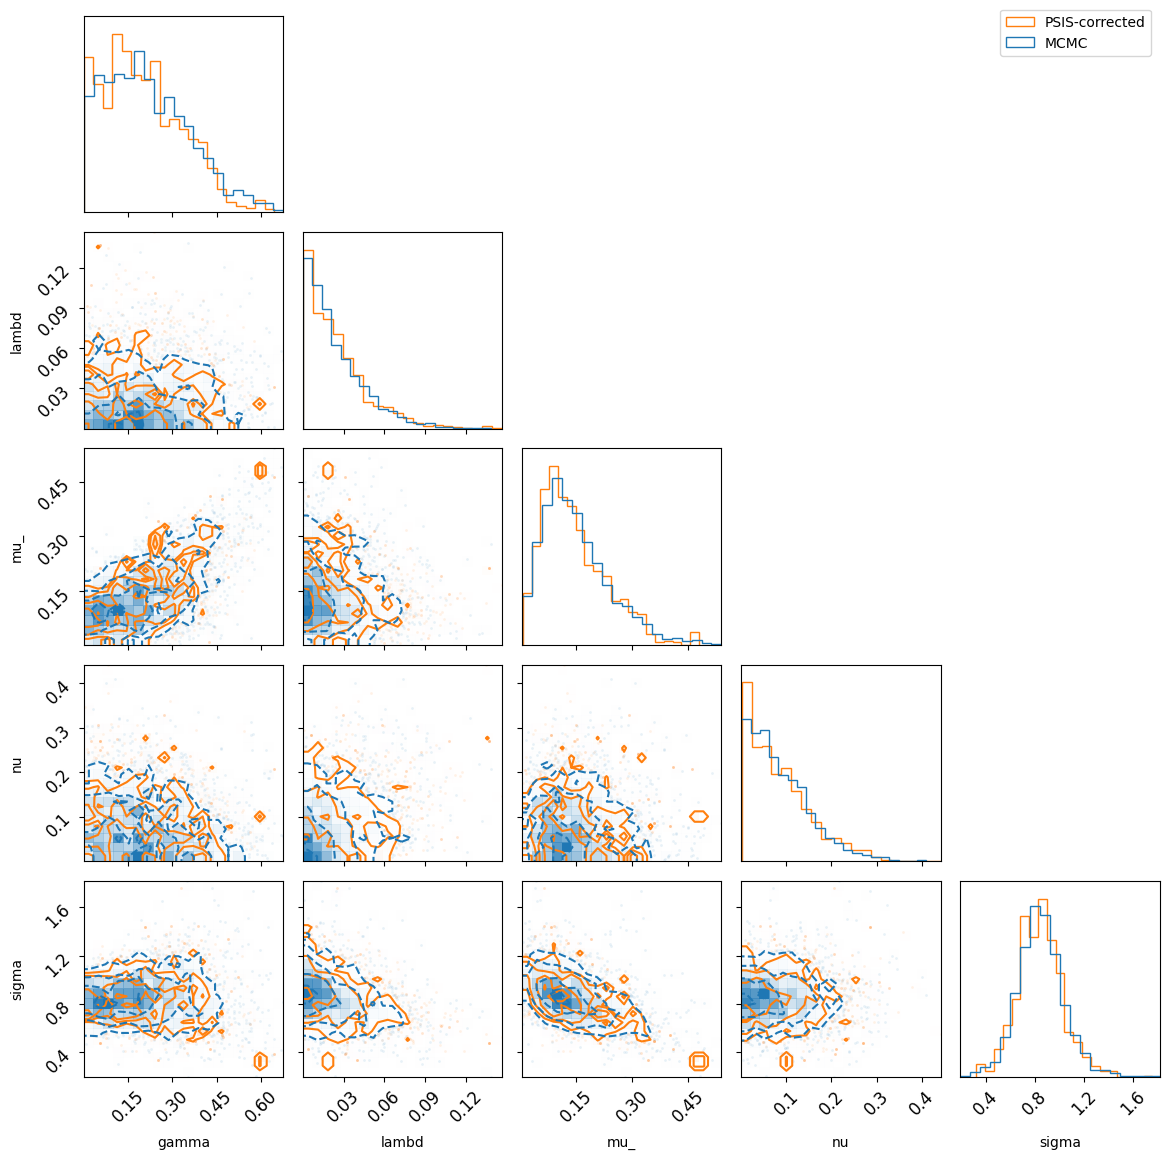

In [17]:
posterior_draws_mcmc = mcmc_result.draws.reshape(
    -1, mcmc_result.draws.shape[-1]
)

# Similarly, we can compare the MCMC-corrected posterior draws with the PSIS-corrected draws (or the original amortized draws) to see how much they differ.
_ = corner_plot(
    posterior_draws_psis,
    posterior_draws_mcmc,
    labels=["PSIS-corrected", "MCMC"],
    var_names=task.var_names,
    transform=task.transform_to_constrained_space,
)

---

## Run inference for many datasets on one call

This notebook serves as a reusable template for new tasks and datasets. We also provide a convenient `runner.run(...)` for demonstrating running the full inference phase for many datasets in one call. (In practice, you may want to use SLURM or other cluster computing systems for embarrassingly parallel runs of many datasets. Also note that the amortized posterior draws and their log-densities can be generated in batches and stored on disk first. These are implementation details that can be customized for advanced use cases.)


In [18]:
from pathlib import Path
from amortized_bayesian_workflow import (
    ArtifactLayout,
    InferenceConfig,
    InferenceRunner,
)
from amortized_bayesian_workflow.tasks.examples import PsychometricTask
from amortized_bayesian_workflow.utils import read_from_file
from amortized_bayesian_workflow.approximators import (
    BayesFlowAmortizedPosterior,
)

task = PsychometricTask(overdispersion=True)
layout = ArtifactLayout(
    root=Path("./artifacts"),
    task_name=task.task_name,
)
config = InferenceConfig(
    mcmc_backend="blackjax_chees_hmc",
    seed=2026,
    rewrite_persisted_dataset_results=True,
)

approximator = BayesFlowAmortizedPosterior.load(layout.models_dir)
runner = InferenceRunner(task=task, approximator=approximator, config=config)


test_observations = read_from_file(task.task_info_dir / "test_datasets.pkl")[
    :2
]
report = runner.run(test_observations)
report.summary_table()

Processing datasets: 100%|██████████| 2/2 [00:03<00:00,  1.95s/it]


[{'dataset_id': 0,
  'status': 'success',
  'message': 'Mahalanobis diagnostic accepted amortized posterior draws.',
  'posterior_source': 'amortized',
  'mcmc_backend': None,
  'error': None},
 {'dataset_id': 1,
  'status': 'success',
  'message': 'Mahalanobis diagnostic accepted amortized posterior draws.',
  'posterior_source': 'amortized',
  'mcmc_backend': None,
  'error': None}]

---

## Citation

LI, C., Vehtari, A., Bürkner, P.-C., Radev, S. T., Acerbi, L., & Schmitt, M. (2026). Amortized Bayesian workflow. Transactions on Machine Learning Research.

### BibTeX

```bibtex
@article{liAmortizedBayesianWorkflow2026,
  title = {Amortized {{Bayesian}} Workflow},
  author = {LI, Chengkun and Vehtari, Aki and B{\"u}rkner, Paul-Christian and Radev, Stefan T. and Acerbi, Luigi and Schmitt, Marvin},
  year = 2026,
  journal = {Transactions on Machine Learning Research}
}
```
